# Reinforcement Learning Capstone: LineWorld Agent

            ## 1. Learning objectives

            - Define success before training
- Compare Q-learning and SARSA across seeds
- Select, evaluate, and critique a final agent

            ## 2. Prerequisites

            Python loops, NumPy arrays, probability, expected value, and basic supervised-learning vocabulary.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")


def plot_rl_metrics(rewards, exploration_rates, episode_lengths, title):
    rewards = np.asarray(rewards, dtype=float)
    window = min(20, len(rewards))
    moving = np.convolve(rewards, np.ones(window)/window, mode="valid")
    episodes = np.arange(1, len(rewards)+1)
    figure, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
    axes[0].plot(episodes, rewards, alpha=.35, color=COURSE_COLORS["blue"], label="Episode reward")
    axes[0].plot(episodes[window-1:], moving, color=COURSE_COLORS["orange"], label=f"{window}-episode average")
    axes[0].set(title=title, ylabel="Reward"); axes[0].legend()
    axes[1].plot(episodes, exploration_rates, color=COURSE_COLORS["olive"])
    axes[1].set(ylabel="Exploration rate")
    axes[2].plot(episodes, episode_lengths, color=COURSE_COLORS["pink"])
    axes[2].set(xlabel="Episode", ylabel="Episode length")
    figure.tight_layout()
    plt.show()

Python lesson ready; reproducible seed = 42


## 3. Problem definition

            Reach a delayed goal quickly in a custom environment; success is high final moving reward and short episodes across seeds.

            ## 4. Real-world use cases

            - Safe algorithm comparison
- Reproducible sequential-decision prototyping
- Training-curve and policy error analysis

            ## 5. Core intuition in simple language

            Build the smallest meaningful environment, establish random exploration, compare on-policy and off-policy control, and require repeatability.

## 6. Mathematical foundation

            $$G_t=\sum_{k=0}^{T-t-1}\gamma^kR_{t+k+1}.$$

            **Every symbol:**

            - $G_t$ is return from time t.
- $R_{t+k+1}$ is a future reward.
- $\gamma\in[0,1]$ is discount factor.
- $T$ is episode end.
- $k$ counts how far a reward is in the future.

            **Why the equation is needed:** Return turns a sequence of delayed rewards into one target for comparing actions and policies.

            **Small numerical example:** With rewards [1,2,3] and gamma=.5, return is 1+.5(2)+.25(3)=2.75.

            **Connection to Python:** sum((gamma**k)*reward for k,reward in enumerate(rewards)) computes the return.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Reset the environment
2. Observe state
3. Choose an action from the policy
4. Receive next state and reward
5. Update values or policy
6. Repeat until termination and across episodes

## 9. Implementation from scratch

A scalar TD update is checked first, then both complete tabular algorithms are implemented with NumPy.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
def q_update(old,reward,next_value,alpha=.3,gamma=.95):
    return old+alpha*(reward+gamma*next_value-old)
print("Example Q update:",round(q_update(.2,0,.8),3))

Example Q update: 0.368


## 10. Implementation using a standard library

No high-level RL algorithm is hidden here; NumPy implements learning and Matplotlib supports auditable curves.

## 11. Dataset loading and exploration

Experience is generated from a documented eight-state LineWorld with two actions, step cost, goal reward, and episode cap.

## 12. Data preprocessing

Discrete states index Q-table rows directly; seeds and episode budgets are held fixed across candidates.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

Q-learning final moving reward: 0.878
SARSA final moving reward: 0.878
Selected Q-table before training:
 [[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]
Selected Q-table during training:
 [[0.57 0.63]
 [0.56 0.68]
 [0.62 0.74]
 [0.68 0.8 ]
 [0.74 0.86]
 [0.8  0.93]
 [0.86 1.  ]
 [0.   0.  ]]
Selected Q-table after training:
 [[0.58 0.63]
 [0.57 0.68]
 [0.63 0.74]
 [0.68 0.8 ]
 [0.74 0.86]
 [0.8  0.93]
 [0.86 1.  ]
 [0.   0.  ]]


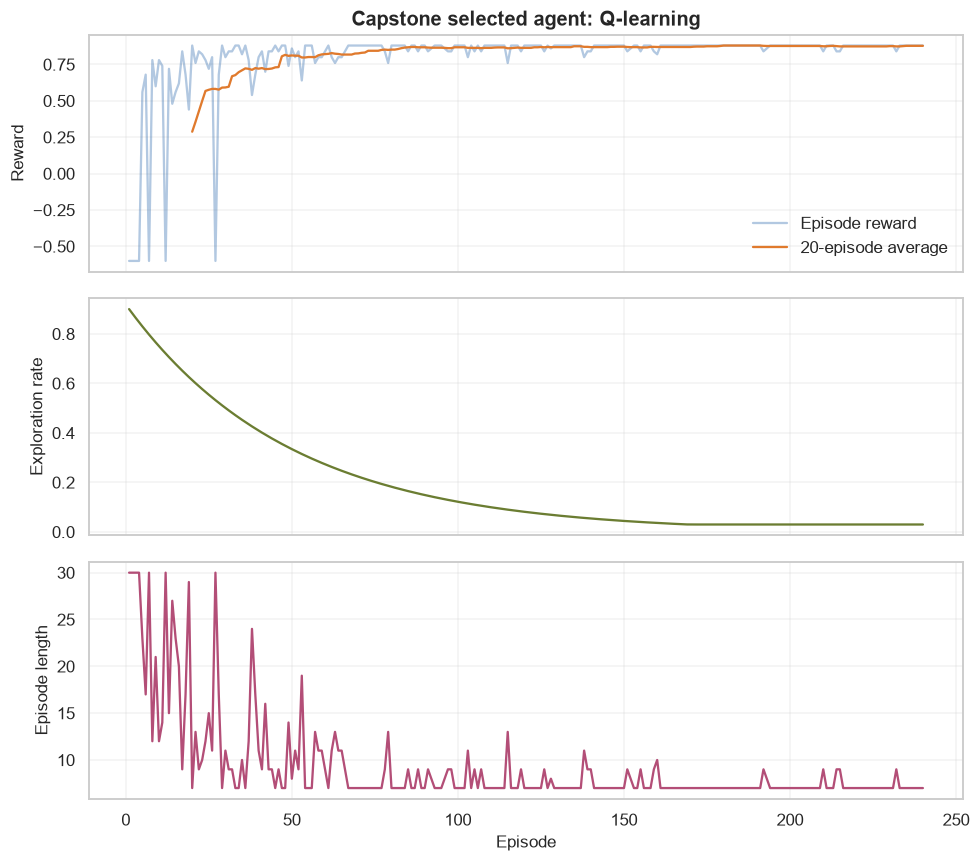

In [3]:
class LineWorld:
    def __init__(self, length=6, max_steps=20):
        self.length=length
        self.max_steps=max_steps
    def reset(self):
        self.state=0
        self.steps=0
        return self.state
    def step(self, action):
        self.steps+=1
        self.state=int(np.clip(self.state + (-1 if action==0 else 1),0,self.length-1))
        terminated=self.state==self.length-1
        truncated=self.steps>=self.max_steps
        reward=1.0 if terminated else -0.02
        return self.state,reward,terminated,truncated

def train(method,seed,episodes=240):
    local_rng=np.random.default_rng(seed); environment=LineWorld(length=8,max_steps=30); Q=np.zeros((environment.length,2))
    rewards=[]; epsilons=[]; lengths=[]; snapshots={0:Q.copy()}
    for episode in range(episodes):
        state=environment.reset(); epsilon=max(.03,.9*(.98**episode)); action=int(local_rng.integers(2)) if local_rng.random()<epsilon else int(np.argmax(Q[state])); total=0
        for step in range(environment.max_steps):
            next_state,reward,terminated,truncated=environment.step(action)
            next_action=int(local_rng.integers(2)) if local_rng.random()<epsilon else int(np.argmax(Q[next_state]))
            next_value=Q[next_state,next_action] if method=="SARSA" else np.max(Q[next_state])
            target=reward+(0 if terminated else .95*next_value)
            Q[state,action]+=.3*(target-Q[state,action])
            state=next_state; action=next_action; total+=reward
            if terminated or truncated: break
        rewards.append(total); epsilons.append(epsilon); lengths.append(step+1)
        if episode+1==episodes//2: snapshots[episode+1]=Q.copy()
    snapshots[episodes]=Q.copy()
    return Q,np.array(rewards),epsilons,lengths,snapshots

results={}
for method in ["Q-learning","SARSA"]:
    results[method]=train(method,RANDOM_SEED)
    print(method,"final moving reward:",round(results[method][1][-20:].mean(),3))
best_method=max(results,key=lambda name:results[name][1][-20:].mean())
Q,rewards,epsilons,lengths,snapshots=results[best_method]
print("Selected Q-table before training:\n",snapshots[0].round(2))
print("Selected Q-table during training:\n",snapshots[120].round(2))
print("Selected Q-table after training:\n",snapshots[240].round(2))
plot_rl_metrics(rewards,epsilons,lengths,f"Capstone selected agent: {best_method}")

**How to interpret the result:** The selected agent has the stronger final moving reward for the primary seed; the multi-seed table determines whether that advantage is repeatable.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

The final comparison uses three seeds rather than selecting a lucky run. Mean and standard deviation quantify variability.

,method,seed,final_reward,final_length
0,Q-learning,7,0.876,7.2
1,Q-learning,21,0.880,7.0
2,Q-learning,42,0.878,7.1
3,SARSA,7,0.876,7.2
4,SARSA,21,0.880,7.0
5,SARSA,42,0.878,7.1


final_reward        final_length     
                   mean    std         mean  std
method                                          
Q-learning        0.878  0.002          7.1  0.1
SARSA             0.878  0.002          7.1  0.1

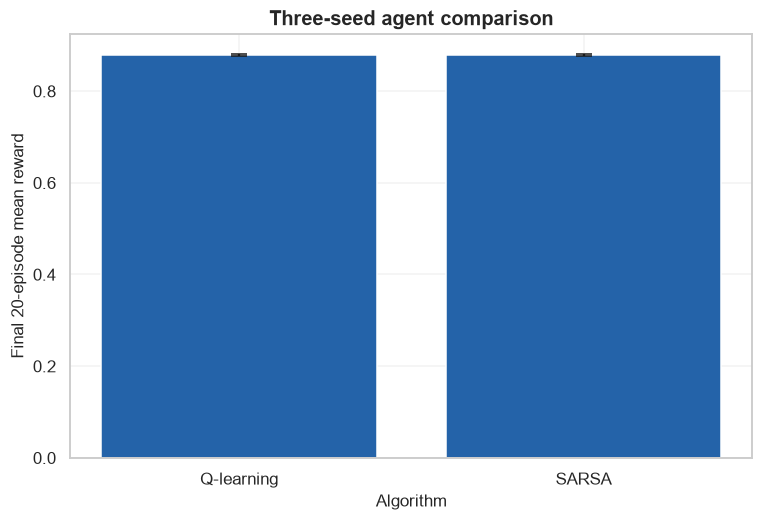

In [4]:
summary=[]
for method in ["Q-learning","SARSA"]:
    for seed in [7,21,42]:
        _,seed_rewards,_,seed_lengths,_=train(method,seed)
        summary.append({"method":method,"seed":seed,"final_reward":seed_rewards[-20:].mean(),"final_length":np.mean(seed_lengths[-20:])})
summary=pd.DataFrame(summary)
display(summary.round(3))
aggregate=summary.groupby("method")[["final_reward","final_length"]].agg(["mean","std"])
display(aggregate.round(3))
figure,axis=plt.subplots()
means=summary.groupby("method")["final_reward"].mean(); stds=summary.groupby("method")["final_reward"].std()
axis.bar(means.index,means.values,yerr=stds.values,color=COURSE_COLORS["blue"],capsize=5)
axis.set(title="Three-seed agent comparison",xlabel="Algorithm",ylabel="Final 20-episode mean reward")
plt.show()

## 18. Common mistakes

            - Selecting the best seed
- Changing episode budgets between candidates
- Reporting reward without episode length
- Ignoring environment simplifications

            ## 19. Advantages and disadvantages

            **Advantages**

            - Transparent reproducible environment
- Baseline and multiple-algorithm comparison
- Multi-seed uncertainty check

            **Disadvantages**

            - Tiny discrete state space
- Reward design is simplified
- No safety or off-distribution evaluation

            ## 20. When to use and when not to use the algorithm

            **Use it when:** actions influence future states and the objective is naturally expressed through cumulative reward.

            **Do not use it when:** a static labeled prediction problem is sufficient or unsafe exploration cannot be controlled.

## 21. Exercises

1. **Conceptual:** Why compare the same seeds?
2. **Mathematical/hand calculation:** For old Q=.4, reward=1, terminal=True, alpha=.5, calculate new Q.
3. **Coding/experimentation:** Add a small stochastic action-slip probability and rerun the comparison.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. Matched seeds reduce variation from different random experiences and make comparison fairer.
2. Terminal target is 1, so new Q=.4+.5(1-.4)=.7.
3. With probability p replace the chosen action by the other action, keep p fixed for both methods, and compare multi-seed reward and length.

</details>

## Capstone delivery checklist

- **Business or real-world problem and success metric:** defined before modeling in the problem-definition section.
- **Dataset description and exploratory data analysis:** documented beside the bounded dataset preview and audit outputs.
- **Data cleaning and feature engineering:** performed after the split where fitting or target information could otherwise leak; choices are stated explicitly, including when no cleaning is required.
- **Baseline and multiple-model comparison:** a simple reference model is evaluated before more flexible candidates.
- **Hyperparameter tuning:** candidates are selected only with development or validation evidence.
- **Final evaluation and error analysis:** the frozen choice is assessed on untouched data with a task-appropriate diagnostic plot.
- **Limitations and possible improvements:** recorded with the disadvantages and interpretation so the result is not overstated.
- **Final conclusion:** the summary connects the evidence, limitations, and next steps.

## 23. Summary and key takeaways

            - A real RL result includes environment and reward definitions
- Q-tables reveal what the agent learned
- Reward, moving reward, exploration, and length tell complementary stories
- Multiple seeds and limitations are required for a credible conclusion

            ## 24. Further reading

            - [Gymnasium documentation](https://gymnasium.farama.org/)
- [Sutton and Barto: Reinforcement Learning](http://incompleteideas.net/book/the-book-2nd.html)